# Specimen 03 — House Price Regression

Goal: same skeleton, continuous target. Model choice matters more here than on Iris.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score


## 1. Load & inspect

`sklearn.datasets.fetch_california_housing()`. Check target distribution shape (skew?).

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64
0.9777632739098335


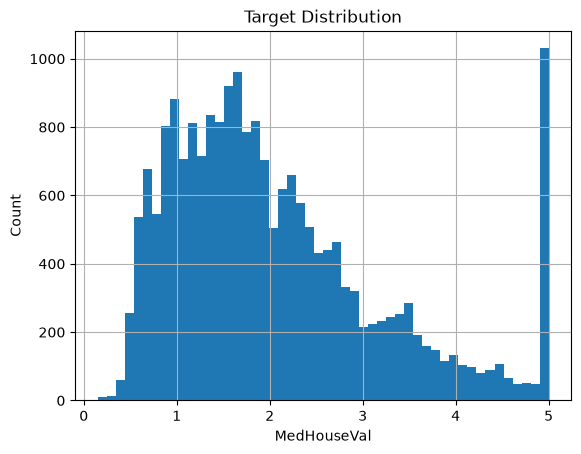

In [ ]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from sklearn.datasets import fetch_california_housing

# Load the California housing dataset using the fetch_california_housing function from scikit-learn. The dataset is loaded as a pandas DataFrame by setting the as_frame parameter to True. The resulting DataFrame is stored in the variable df for further analysis and exploration.
housing = fetch_california_housing(as_frame=True)
df = housing.frame
# Display the shape of the DataFrame (number of rows and columns) and the first few rows of the dataset using the head() method. This provides an overview of the dataset's structure and allows for a quick inspection of the data.
print(df.shape)
print(df.head())
# Display summary statistics for the 'MedHouseVal' column, which represents the median house value in the California housing dataset. The describe() method provides key statistics such as count, mean, standard deviation, minimum, maximum, and quartiles. Additionally, the skew() method is used to calculate the skewness of the 'MedHouseVal' distribution, which indicates the asymmetry of the data.
print(df['MedHouseVal'].describe())
print(df['MedHouseVal'].skew())

# Create a histogram of the 'MedHouseVal' column to visualize the distribution of median house values in the California housing dataset. The histogram is created using the hist() method, with 50 bins specified for better granularity. The x-axis is labeled as 'MedHouseVal', the y-axis as 'Count', and a title 'Target Distribution' is added to provide context for the plot. Finally, plt.show() is called to display the histogram.
df['MedHouseVal'].hist(bins=50)
plt.xlabel('MedHouseVal')
plt.ylabel('Count')
plt.title('Target Distribution')
plt.show()

## 2. Correlation pass

Heatmap feature correlations with target and each other. Flag redundant pairs.

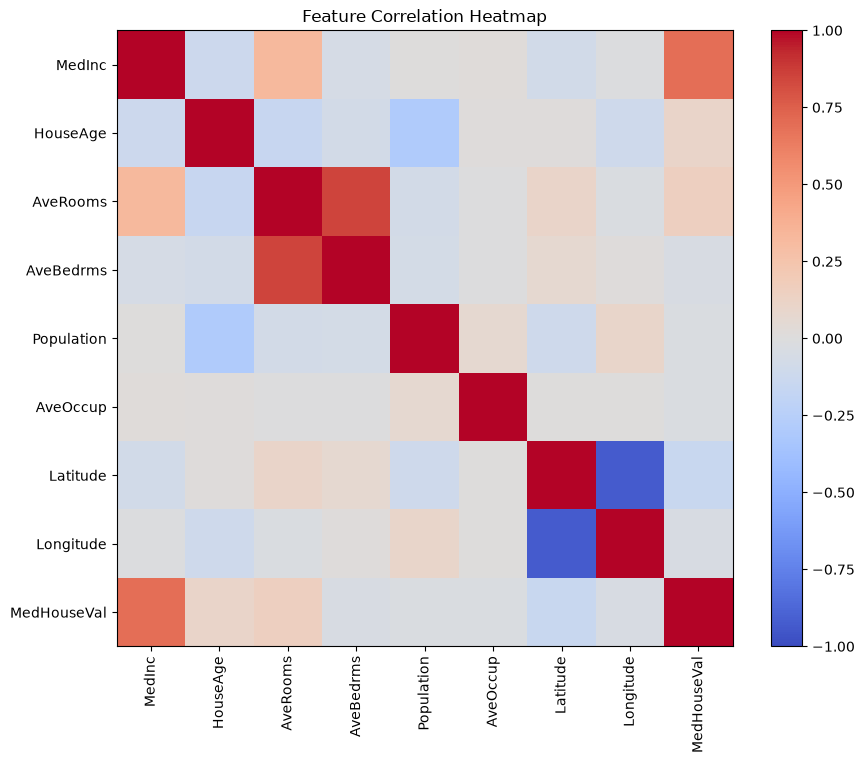

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64
Longitude    Latitude       0.924664
AveRooms     AveBedrms      0.847621
MedHouseVal  MedInc         0.688075
MedInc       AveRooms       0.326895
HouseAge     Population     0.296244
AveRooms     HouseAge       0.153277
MedHouseVal  AveRooms       0.151948
Latitude     MedHouseVal    0.144160
HouseAge     MedInc         0.119034
Latitude     Population     0.108785
dtype: float64


In [ ]:
# Calculate the correlation matrix of the DataFrame using the corr() method. The correlation matrix provides insights into the relationships between different features in the dataset, with values ranging from -1 (perfect negative correlation) to 1 (perfect positive correlation). The resulting correlation matrix is stored in the variable corr for further analysis and visualization.
corr = df.corr()
# Create a heatmap to visualize the correlation matrix using matplotlib. The heatmap is created with a figure size of 10x8 inches, and the correlation values are displayed using the 'coolwarm' colormap. The color scale is set to range from -1 to 1, and a colorbar is added for reference. The x-axis and y-axis ticks are labeled with the feature names, rotated for better readability. Finally, a title 'Feature Correlation Heatmap' is added, and plt.show() is called to display the heatmap.
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Feature Correlation Heatmap')
plt.show()

# Print the correlation values of the 'MedHouseVal' column with all other features in the dataset. The correlation values are sorted in descending order to identify which features have the strongest positive or negative relationships with the target variable 'MedHouseVal'. This information can be useful for feature selection and understanding the factors that influence median house values in the California housing dataset.
print(corr['MedHouseVal'].sort_values(ascending=False))

# Identify pairs of features with high correlation (absolute value greater than 0.5) to detect potential multicollinearity issues. The correlation matrix is unstacked and sorted in descending order, and pairs with a correlation value of 1 (self-correlation) are excluded. The resulting pairs are printed, showing the top 10 feature pairs with the highest absolute correlation values, which can help inform feature selection and model building decisions.
pairs = corr.abs().unstack().sort_values(ascending=False)
pairs = pairs[pairs < 1]
print(pairs.drop_duplicates().head(10))

## 3. Train/test split

Plain random split is fine. Hold it out until the end.

In [ ]:
# Split the dataset into features (X) and target variable (y). The features are obtained by dropping the 'MedHouseVal' column from the DataFrame, while the target variable is set to the 'MedHouseVal' column. The resulting feature set (X) and target variable (y) are then used for model training and evaluation.
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

# Split the dataset into training and testing sets using the train_test_split function from scikit-learn. The test_size parameter is set to 0.2, indicating that 20% of the data will be used for testing, while the remaining 80% will be used for training. The random_state parameter is set to 42 to ensure reproducibility of the results. The resulting training and testing sets are stored in X_train, X_test, y_train, and y_test variables for further model development and evaluation.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the training and testing feature sets (X_train and X_test) to verify the number of samples and features in each set. This provides an overview of the dataset split and ensures that the training and testing sets have been created correctly.
print(X_train.shape, X_test.shape)

(16512, 8) (4128, 8)


## 4. Baseline: linear regression

Note RMSE and R². This floor will be low on this dataset.

In [ ]:
from sklearn.linear_model import LinearRegression
# Root Mean Squared Error (RMSE) and R-squared (R^2) are two commonly used metrics to evaluate the performance of regression models. RMSE measures the average magnitude of the errors between predicted and actual values, while R^2 indicates the proportion of variance in the dependent variable that is predictable from the independent variables. In this code snippet, we will fit a Linear Regression model to the training data, make predictions on the test data, and then calculate and print the RMSE and R^2 scores for the model's performance evaluation.
from sklearn.metrics import root_mean_squared_error, r2_score

# Fit a Linear Regression model to the training data, make predictions on the test data, and calculate the RMSE and R^2 scores for performance evaluation.
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Calculate the Root Mean Squared Error (RMSE) and R-squared (R^2) scores for the Linear Regression model's predictions on the test data. The RMSE is computed using the root_mean_squared_error function, while the R^2 score is calculated using the r2_score function. These metrics provide insights into the model's accuracy and goodness of fit.
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Print the calculated RMSE and R^2 scores for the Linear Regression model's performance evaluation. The RMSE is formatted to three decimal places, and the R^2 score is also formatted to three decimal places for better readability. These printed values provide a summary of the model's predictive accuracy and explanatory power.
print(f"Linear Regression RMSE: {rmse_lr:.3f}")
print(f"Linear Regression R^2: {r2_lr:.3f}")

Linear Regression RMSE: 0.746
Linear Regression R^2: 0.576


## 5. Compare nonlinear models

Random forest regressor, gradient boosting regressor — same CV setup.

In [ ]:
#KFold Cross Validation is a technique used to evaluate the performance of machine learning models by splitting the dataset into multiple subsets (folds) and training/testing the model on different combinations of these folds. In this code snippet, we will use KFold cross-validation to assess the performance of two regression models: Random Forest and Gradient Boosting. The models will be evaluated using the negative root mean squared error (neg_root_mean_squared_error) as the scoring metric, and the results will be printed for each model.
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# Set up KFold cross-validation with 5 splits, shuffling the data before splitting, and setting a random state for reproducibility. The KFold object will be used to generate train/test indices for each fold during the cross-validation process.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform KFold cross-validation for each model in the models dictionary. The cross_val_score function is used to compute the negative root mean squared error (neg_root_mean_squared_error) for each fold of the cross-validation. The results are stored in the cv_results dictionary, and the mean and standard deviation of the scores are printed for each model to provide an overview of their performance.
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error')
    cv_results[name] = -scores
    print(f"{name}: {-scores.mean():.3f} +/- {scores.std():.3f}")

Random Forest: 0.509 +/- 0.012
Gradient Boosting: 0.532 +/- 0.012


## 6. Residual check

Predicted vs. actual, and residuals vs. predicted, for your best model.

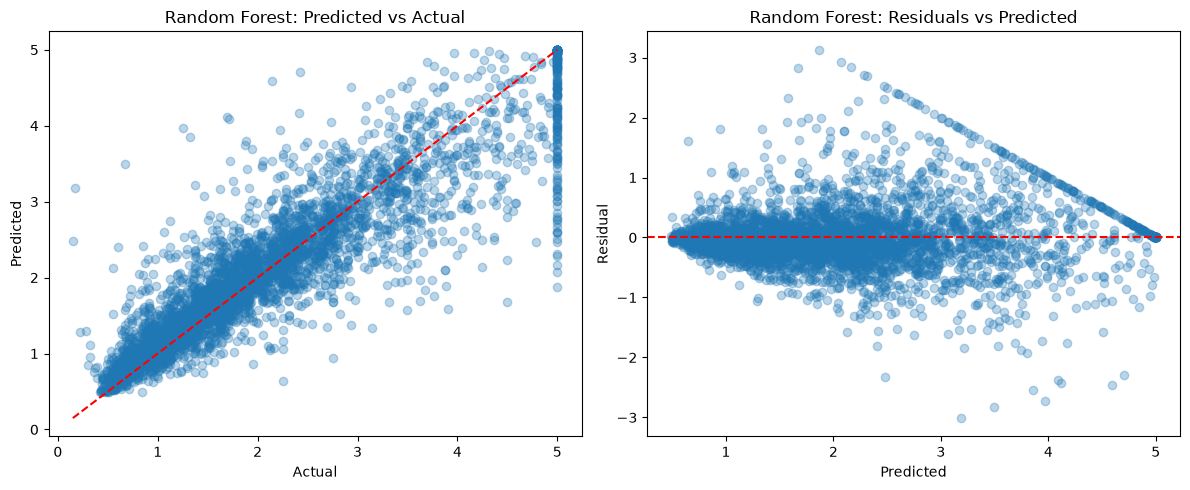

Random Forest


In [ ]:
# Identify the best model based on the mean cross-validation score. The model with the lowest mean RMSE is selected as the best model. The best model is then fitted to the training data, and predictions are made on the test data. Finally, two plots are created: one showing the predicted vs actual values and another showing the residuals vs predicted values for the best model. The name of the best model is printed for reference.
best_name = min(cv_results, key=lambda k: cv_results[k].mean())
best_model = models[best_name]
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

# Create plots for the best model's performance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_best, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'{best_name}: Predicted vs Actual')

plt.subplot(1, 2, 2)
residuals = y_test - y_pred_best
plt.scatter(y_pred_best, residuals, alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title(f'{best_name}: Residuals vs Predicted')

plt.tight_layout()
plt.show()

print(best_name)

## 7. Feature importance

Sanity-check against domain intuition.

MedInc        0.526
AveOccup      0.138
Latitude      0.089
Longitude     0.088
HouseAge      0.054
AveRooms      0.044
Population    0.031
AveBedrms     0.030
dtype: float64


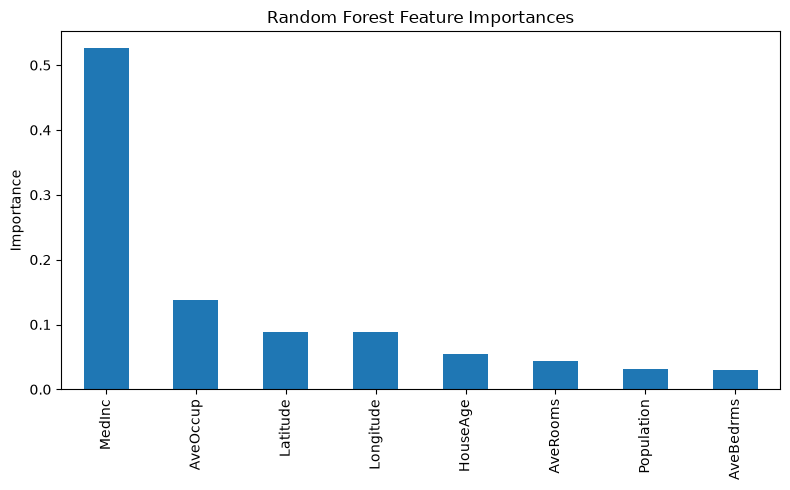

In [ ]:
# Calculate feature importances for the best model
importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.round(3))

# Create a bar plot to visualize the feature importances of the best model. The feature importances are plotted in descending order, with the y-axis labeled as 'Importance' and a title indicating the best model's name. The figure size is set to 8x5 inches, and plt.tight_layout() is called to ensure proper spacing of the plot elements before displaying the plot with plt.show().
plt.figure(figsize=(8, 5))
importances.plot(kind='bar')
plt.ylabel('Importance')
plt.title(f'{best_name} Feature Importances')
plt.tight_layout()
plt.show()

## 8. Final test evaluation

Report RMSE and R² on the held-out test set, once.

In [ ]:
# Calculate the Root Mean Squared Error (RMSE) and R-squared (R^2) scores for the best model's predictions on the test data. The RMSE is computed using the root_mean_squared_error function, while the R^2 score is calculated using the r2_score function. These metrics provide insights into the model's accuracy and goodness of fit.
rmse_final = root_mean_squared_error(y_test, y_pred_best)
r2_final = r2_score(y_test, y_pred_best)

# Print the calculated RMSE and R^2 scores for the best model's performance evaluation. The RMSE is formatted to three decimal places, and the R^2 score is also formatted to three decimal places for better readability. These printed values provide a summary of the model's predictive accuracy and explanatory power.
print(f"{best_name} Test RMSE: {rmse_final:.3f}")
print(f"{best_name} Test R^2: {r2_final:.3f}")

Random Forest Test RMSE: 0.504
Random Forest Test R^2: 0.806
